# 여러 영상 검색 RAG: 근거 프레임으로 OpenAI 답변 만들기

비디오 검색 RAG는 질문과 가까운 프레임 설명을 Vector DB에서 찾고, 검색된 설명만 근거로 답을 생성하는 흐름이다. 이 실습은 아홉 영상의 공통 Chroma collection을 검색하고, LLM이 선택한 `evidence_rank`를 실제 DB metadata에 연결한다.


## 전체 처리 흐름

LLM은 자연어 답변과 근거 순위만 결정한다. `video_id`, `frame_path`, `timestamp_sec`처럼 원본이 이미 알고 있는 값은 생성시키지 않는다. 이렇게 하면 자연스러운 답변과 출처 정보를 분리하여 출처 환각을 줄일 수 있다.

```mermaid
flowchart TD
    A["05의 mixkit_9_v1<br/>Chroma collection"] --> D["chunk 후보 over-fetch"]
    Q["사용자 질문"] --> B["같은 OpenAI embedding model"]
    B --> D
    D --> E["frame_id 중복 제거"]
    E --> F["rank가 붙은 top-k context"]
    F --> G["ChatOpenAI:<br/>found·answer·evidence_rank"]
    G --> H["evidence_rank 선택"]
    E --> H
    H --> I["DB metadata에서<br/>video·frame·timestamp 결정"]
    I --> J["답변·영상·근거 프레임 표시"]
```


## 실행 환경과 API 설정

05를 먼저 실행해 `mixkit_9_v1` Chroma collection을 만들어야 한다. 질문 embedding과 ChatOpenAI 답변 생성은 OpenAI API를 호출하므로 사용량에 따른 비용이 발생한다.

```bash
pip install chromadb==1.5.9 langchain-openai==1.5.2 python-dotenv==1.2.3 pydantic pandas pillow matplotlib
```

실제 key는 `.env`에서 불러오며 source나 출력에 표시하지 않는다. 이 교안에는 `gpt-5.6-luna`로 대표 질문과 11개 평가 질문을 실제 실행한 결과가 저장되어 있다.


In [1]:
%pip install chromadb==1.5.9 langchain-openai==1.5.2 python-dotenv==1.2.3 pydantic pandas pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


## Chroma collection과 OpenAI model 준비하기

질문 embedding은 05에서 저장한 caption embedding과 같은 model을 사용해야 한다. `MIN_SIMILARITY`는 검색 결과가 corpus와 충분히 가까운지 판단하는 수업용 기준이다. 절대적인 정답 기준이 아니므로 실제 positive·negative 결과를 관찰한 뒤 조정한다.


In [2]:
import os
from pathlib import Path

import chromadb
from dotenv import find_dotenv, load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

ENV_PATH = find_dotenv(usecwd=True)
load_dotenv(ENV_PATH)

CORPUS_ID = 'mixkit_9_v1'
ARTIFACT_ROOT = Path('artifacts/multimodal_rag') / CORPUS_ID
COMMENT_DIR = ARTIFACT_ROOT / 'comments'
VIDEO_MANIFEST_PATH = ARTIFACT_ROOT / 'video_manifest.jsonl'
FRAME_MANIFEST_PATH = ARTIFACT_ROOT / 'frame_manifest.jsonl'
CHROMA_DIR = ARTIFACT_ROOT / 'chroma'
COLLECTION_NAME = 'video_frame_descriptions_openai_mixkit9_v1'
EMBEDDING_MODEL_ID = os.getenv('OPENAI_EMBEDDING_MODEL') or 'text-embedding-3-small'
CHAT_MODEL_ID = os.getenv('OPENAI_CHAT_MODEL') or 'gpt-5.6-luna'
MIN_SIMILARITY = 0.25

chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# 프레임 이미지 54개의 설명을 임베딩해서 저장한 VectorDB Load
frame_collection = chroma_client.get_collection(name=COLLECTION_NAME)

# 사용자 입력을 임베딩하기위한 용도
embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL_ID)

# Vector 검색 결과(근거)를 이용하여 메시지를 생성할 LLM
chat_model = ChatOpenAI(
    model=CHAT_MODEL_ID,
    reasoning_effort='low' # 추론 레벨
)

print(f'corpus_id={CORPUS_ID}')
print(f'collection_count={frame_collection.count()}')
print(f'embedding_model={EMBEDDING_MODEL_ID}')
print(f'chat_model={CHAT_MODEL_ID}')
print(f'min_similarity={MIN_SIMILARITY}')


corpus_id=mixkit_9_v1
collection_count=54
embedding_model=text-embedding-3-small
chat_model=gpt-5.6-luna
min_similarity=0.25


## 질문마다 서로 다른 top-k 프레임 검색하기

상세 설명 하나가 여러 chunk로 나뉘므로 필요한 결과 수보다 많은 chunk를 먼저 가져온다. 가까운 순서대로 처음 등장한 `frame_id`만 남기면 top-k가 서로 다른 실제 장면으로 구성된다.


In [3]:
def retrieve_unique_frames(question: str, top_k: int = 4, overfetch_factor: int = 5):

    question_embedding = embedding_model.embed_query(question)
    candidate_count = min(
        frame_collection.count(),
        max(top_k, top_k * overfetch_factor),
    )

    raw_result = frame_collection.query(
        query_embeddings=[question_embedding],
        n_results=candidate_count,
        include=['documents', 'metadatas', 'distances'],
    )

    results = []
    seen_frame_ids = set()
    candidates = zip(
        raw_result['ids'][0],
        raw_result['documents'][0],
        raw_result['metadatas'][0],
        raw_result['distances'][0],
    )
    for chunk_id, text, metadata, distance in candidates:
        if metadata['frame_id'] in seen_frame_ids:
            continue
        seen_frame_ids.add(metadata['frame_id'])
        results.append({
            'chunk_id': chunk_id,
            'text': text,
            'metadata': metadata,
            'distance': float(distance),
            'similarity': 1.0 - float(distance),
        })
        if len(results) == top_k:
            break
    return results

## LLM이 생성할 구조 제한하기

Structured output은 모델 응답을 정해진 필드로 제한하는 방식이다. `found`는 근거 존재 여부, `answer`는 질문에 대한 짧은 답, `evidence_rank`는 검색 결과 중 선택한 순위이다. 영상 파일명이나 프레임 경로는 LLM 출력에 포함하지 않는다.


In [4]:
from pydantic import BaseModel, Field

class RagDecision(BaseModel):

    found: bool = Field(description='검색된 설명에 질문의 답이 직접 있으면 true이다.')
    answer: str = Field(description='검색 근거만 사용한 짧은 한국어 답변이다.')
    evidence_rank: int | None = Field(
        description='found가 true이면 1부터 시작하는 근거 rank이고, false이면 null이다.'
    )

decision_model = chat_model.with_structured_output(RagDecision)


## 검색과 답변을 하나의 RAG 함수로 연결하기

Context에는 rank, 영상 ID, 시각과 설명 chunk를 넣어 모델이 어떤 근거를 선택했는지 밝히게 한다. 모델이 반환한 rank가 범위를 벗어나거나 top-1 similarity가 임계값보다 낮으면 근거 없음으로 처리한다. 최종 영상·프레임 정보는 선택한 검색 결과의 metadata에서 코드가 가져온다.


In [5]:
def answer_video_question(question: str, top_k: int = 4):
    # 1단계는 질문과 가까운 서로 다른 실제 프레임을 검색하는 과정이다.
    search_results = retrieve_unique_frames(question, top_k=top_k)
    context = '\n\n'.join(
        (
            f"Rank {rank}\n"
            f"video_id: {result['metadata']['video_id']}\n"
            f"timestamp_sec: {float(result['metadata']['timestamp_sec']):.2f}\n"
            f"description: {result['text']}"
        )
        for rank, result in enumerate(search_results, start=1)
    )

    # 2단계는 rank가 붙은 검색 context만 LLM에 전달해 구조화 판단을 받는 과정이다.
    decision = decision_model.invoke([
        (
            'system',
            '검색된 프레임 설명만 사용해 답한다. 답이 직접 없으면 found=false로 판단한다. '
            'found=true이면 답을 뒷받침하는 하나의 evidence_rank를 선택한다.',
        ),
        ('human', f'질문: {question}\n\n검색 결과:\n{context}'),
    ])

    # similarity 기준과 rank 범위는 LLM이 아닌 코드가 검증한다.
    valid_rank = (
        decision.evidence_rank is not None
        and 1 <= decision.evidence_rank <= len(search_results)
    )
    selected_candidate = search_results[decision.evidence_rank - 1] if valid_rank else None

    passes_threshold = (
        selected_candidate is not None
        and selected_candidate['similarity'] >= MIN_SIMILARITY
    )
    # 3단계는 LLM 판단, rank 범위와 similarity 기준이 모두 맞을 때만 근거를 채택하는 과정이다.
    found = bool(decision.found and valid_rank and passes_threshold)
    evidence = selected_candidate if found else None

    return {
        'question': question,
        'found': found,
        'answer': decision.answer if found else '검색된 프레임에서 근거를 찾지 못했다.',
        'evidence_rank': decision.evidence_rank if found else None,
        'evidence': evidence,
        'search_results': search_results,
    }

## 답변과 검색 근거 표시하기

검색 표는 LLM에 전달된 rank 순서를 그대로 사용한다. 답변 아래에는 선택된 실제 프레임과 로컬 비디오 플레이어를 표시한다. `embed=False`는 MP4 전체를 notebook output에 base64로 저장하지 않고 파일 경로를 참조한다.


In [6]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, Video, display
from PIL import Image

def display_rag_result(result: dict):

    lines = [
        '| rank | video_id | timestamp | similarity | description chunk |',
        '|---:|---|---:|---:|---|',
    ]
    for rank, item in enumerate(result['search_results'], start=1):
        metadata = item['metadata']
        safe_text = item['text'].replace('|', '&#124;').replace('\n', ' ')
        lines.append(
            f"| {rank} | {metadata['video_id']} | {float(metadata['timestamp_sec']):.2f}s | "
            f"{item['similarity']:.4f} | {safe_text} |"
        )

    display(Markdown(f"**질문:** {result['question']}\n\n" + '\n'.join(lines)))
    print(f"found={result['found']}")
    print(f"answer={result['answer']}")

    if result['evidence'] is None:
        return
    metadata = result['evidence']['metadata']
    print(f"evidence_rank={result['evidence_rank']}")
    print(f"video_id={metadata['video_id']}")
    print(f"timestamp_sec={float(metadata['timestamp_sec']):.2f}")
    print(f"frame_path={metadata['frame_path']}")

    with Image.open(Path(metadata['frame_path'])) as image:
        plt.figure(figsize=(8, 4.5))
        plt.imshow(image.convert('RGB'))
        plt.axis('off')
        plt.title(f"{metadata['video_id']} | {float(metadata['timestamp_sec']):.2f}s")
        plt.show()
    display(Video(str(metadata['video_path']), embed=False, html_attributes='controls'))


## 대표 positive 질문 네 개 실행하기

Positive 질문은 corpus 안에 답이 있는 장면을 묻는다. 강아지, 요리, 서핑과 축구처럼 서로 다른 영상의 결과가 선택되는지 확인한다.


**질문:** 강아지는 입에 무엇을 물고 달리는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | cooking | 7.80s | 0.3310 | 프라이팬 안에 다진 고기와 기름이 들어 있고, 나무 주걱이 놓여 있다.   주걱이 팬 속의 다진 고기를 뒤섞고 있다.   팬은 가스레인지 위에 놓여 있으며, 주변에 여러 개의 버너와 금속 격자가 보인다.   팬의 바깥쪽에는 갈색 얼룩과 사용 흔적이 두드러진다. |
| 2 | soccer | 12.37s | 0.2927 | 축구장에 여러 사람이 서 있으며, 중앙의 인물들은 골대 근처에 모여 있다.   한 사람은 공을 들고 있고, 다른 사람들은 골대 주변에 서 있거나 걷고 있다.   장소는 높은 그물망으로 둘러싸인 야외 인조 잔디 구장이며, 뒤쪽에는 나무가 우거져 있다.   화면 전체에 낮은 시점의 넓은 잔디밭과 골대를 덮는 촘촘한 그물망이 보인다. |
| 3 | cooking | 4.84s | 0.2843 | 프라이팬 안에 잘게 썬 분홍빛 재료가 담겨 있고, 나무 주걱이 팬 위에 놓여 있다.   나무 주걱으로 팬 안의 재료를 저으며 조리하는 모습이 보인다.   팬은 파란 불꽃이 켜진 가스레인지 위에 놓여 있으며, 주변에 여러 개의 화구가 보인다.   팬 가장자리와 바닥에는 갈색의 얼룩과 기름기가 있고, 팬 안쪽에는 작은 갈색 조각들이 흩어져 있다. |
| 4 | running | 12.30s | 0.2839 | 숲길 위에 달리는 사람의 하반신이 보인다.   인물은 운동화를 신고 흙길을 따라 앞으로 달리고 있다.   주변에는 나무가 늘어서 있고 햇빛과 나무 그림자가 비치는 가운데, 뒤에서 낮은 위치로 촬영한 구도가 특징적이다. |

found=False
answer=검색된 프레임에서 근거를 찾지 못했다.


**질문:** 요리사는 음식을 어떻게 준비하고 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | cooking | 7.80s | 0.2094 | 프라이팬 안에 다진 고기와 기름이 들어 있고, 나무 주걱이 놓여 있다.   주걱이 팬 속의 다진 고기를 뒤섞고 있다.   팬은 가스레인지 위에 놓여 있으며, 주변에 여러 개의 버너와 금속 격자가 보인다.   팬의 바깥쪽에는 갈색 얼룩과 사용 흔적이 두드러진다. |
| 2 | cooking | 6.34s | 0.1776 | 검은 프라이팬 안에 잘게 썬 양파와 갈색 재료가 담겨 있고, 나무 주걱이 놓여 있다.   프라이팬은 가스레인지 위에 놓여 있으며, 주걱이 팬 안의 재료를 젓고 있다.   주변에는 여러 개의 금속 화구가 보이고, 프라이팬 바깥쪽에는 기름때와 사용 흔적이 두드러진다. |
| 3 | swimming | 9.47s | 0.1657 | 넓은 수영장 물속 중앙에 사람으로 보이는 형체가 부분적으로 잠겨 있다.   수면에는 잔물결과 반사광이 퍼져 있다.   수영장 뒤로 기와지붕이 있는 건물과 덮개가 있는 테라스, 의자와 울타리가 보인다.   맑고 선명한 청록색 물과 강한 햇빛 반사가 장면의 두드러진 시각적 특징이다. |
| 4 | basketball | 13.42s | 0.1593 | 검은색 민소매 상의와 반바지를 입은 사람이 스케이트보드 위에 서 있다.   그는 야외 코트에서 한쪽 발을 보드에 올린 채 이동하는 모습이다.   주변에는 계단, 콘크리트 벽, 나무와 화단, 벤치가 있으며 바닥에는 흰 선과 붉은색 원형 표식이 보인다. |

found=False
answer=검색된 프레임에서 근거를 찾지 못했다.


**질문:** 서퍼는 파도 위에서 무엇을 하고 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | surfing | 0.92s | 0.4735 | 바다 위에 여러 명의 서퍼가 보이며, 일부는 파도 위에서 서핑을 하고 있습니다.   넓은 바다에 낮고 길게 형성된 파도가 펼쳐져 있고, 먼 곳에도 서퍼들이 흩어져 있습니다.   배경에는 흐린 하늘과 안개 낀 산 능선이 보이며, 전체적으로 푸른 회색빛의 차분한 풍경입니다. |
| 2 | surfing | 10.64s | 0.4610 | 넓은 바다 위에 큰 흰 파도가 일고 있으며, 두 명의 서퍼가 보인다. 오른쪽 서퍼는 파도의 경사진 면에서 보드 위에 올라타고 있고, 왼쪽 서퍼는 잔잔한 수면에서 보드에 엎드려 있다. 뒤쪽에는 안개 낀 해안선과 낮은 산들이 희미하게 보인다. 전체 장면은 회색빛 바다와 짙은 흰 물거품이 대비되는 모습이다. |
| 3 | surfing | 4.17s | 0.4526 | 바다 위에 서퍼 한 명과 서핑보드가 보인다.   서퍼는 밀려오는 파도를 타고 이동하고 있으며, 왼쪽에는 하얀 포말이 일고 있다.   주변은 넓은 바다이고, 뒤쪽에는 안개 낀 듯한 산 능선이 희미하게 보인다.   전체적으로 흐린 하늘과 푸른 회색 바다가 어우러진 장면이다. |
| 4 | surfing | 13.89s | 0.3530 | 화면 중앙에서 오른쪽으로 큰 파도가 일어나며, 파도 위쪽에 작은 검은 형체가 보인다.   파도는 흰 거품을 만들며 바다 쪽으로 길게 부서지고 있고, 아래쪽에도 흰색 물체 일부가 드러나 있다.   장면은 넓은 바다를 내려다본 모습으로, 뒤편에는 흐릿한 산 능선과 흐 |

found=True
answer=서퍼는 파도 위에서 서핑을 하며 이동하고 있습니다.
evidence_rank=3
video_id=surfing
timestamp_sec=4.17
frame_path=artifacts/multimodal_rag/mixkit_9_v1/frames/surfing/surfing_frame0000100.jpg


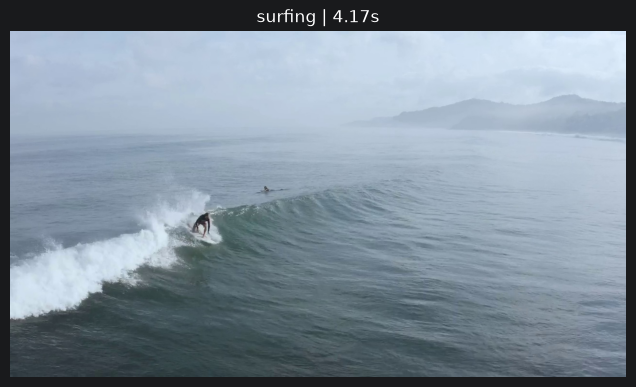

**질문:** 축구 선수는 공으로 무엇을 하고 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | soccer | 5.33s | 0.5439 | 축구장에 여러 명의 선수가 있고, 앞쪽에는 회색 상의와 검은 반바지를 입은 선수가 크게 보인다.   선수들은 골대 방향으로 뛰고 있으며, 왼쪽 선수의 발밑에는 축구공이 보인다.   장면은 높은 철망으로 둘러싸인 인조잔디 구장에서 촬영되었고, 뒤쪽에 골대와 나무, 맑은 하늘이 보인다.   카메라가 지면 가까이에 있어 전경 선수의 하체와 잔디가 크게 강조된 것이 특징이다. |
| 2 | soccer | 10.03s | 0.4693 | 축구공 근처에 초록색 상의를 입은 어린이와 어두운색 옷을 입은 사람이 있고, 옆에는 회색 상의와 검은색 반바지를 입은 성인이 서 있다.   어린이는 공 가까이에 서 있으며, 세 사람은 골대 방향으로 이동하고 있다.   장소는 인조 잔디로 된 축구장이고, 뒤쪽에 흰색 골대와 높은 그물 펜스, 나무들이 보인다.   화면은 낮은 시점에서 촬영되어 잔디가 넓게 보이며, 노란색 축구공과 골대가 시각적으로 두드러진다. |
| 3 | soccer | 3.00s | 0.4640 | 여러 명의 사람들이 축구공 주변에 서 있으며, 초록색 상의를 입은 선수가 공을 바라보고 있다.   앞쪽의 선수들이 인조잔디 위에서 공을 향해 발을 움직이고 있고, 뒤쪽의 한 사람은 골대 앞에 서 있다.   장소는 철망으로 둘러싸인 야외 축구장으로, 뒤편에 나무와 골대가 보인다.   노란색과 파란색 축구공이 화면 중앙 아래쪽에 놓여 있고, 낮은 시점에서 촬영된 장면이다. |
| 4 | soccer | 12.37s | 0.4422 | 축구장에 여러 사람이 서 있으며, 중앙의 인물들은 골대 근처에 모여 있다.   한 사람은 공을 들고 있고, 다른 사람들은 골대 주변에 서 있거나 걷고 있다.   장소는 높은 그물망으로 둘러싸인 야외 인조 잔디 구장이며, 뒤쪽에는 나무가 우거져 있다.   화면 전체에 낮은 시점의 넓은 잔디밭과 골대를 덮는 촘촘한 그물망이 보인다. |

found=True
answer=축구 선수들은 공을 발로 움직이거나 차고 있습니다.
evidence_rank=1
video_id=soccer
timestamp_sec=5.33
frame_path=artifacts/multimodal_rag/mixkit_9_v1/frames/soccer/soccer_frame0000160.jpg


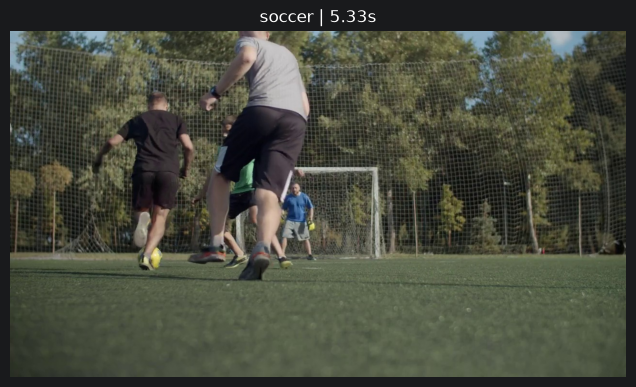

In [7]:
POSITIVE_QUESTIONS = [
    '강아지는 입에 무엇을 물고 달리는가?',
    '요리사는 음식을 어떻게 준비하고 있는가?',
    '서퍼는 파도 위에서 무엇을 하고 있는가?',
    '축구 선수는 공으로 무엇을 하고 있는가?',
]

for question in POSITIVE_QUESTIONS:

    display_rag_result(answer_video_question(question))


## Corpus에 없는 negative 질문 실행하기

Negative 질문은 저장된 아홉 영상에 없는 대상을 묻는다. 비행기 장면처럼 검색 근거가 없는 질문에서 `found=false`가 되는지 확인하고, 잘못 답한다면 `MIN_SIMILARITY`와 prompt를 positive 결과와 함께 조정한다.


In [8]:

negative_result = answer_video_question('비행기가 하늘을 날아가는 장면을 찾아줘')
display_rag_result(negative_result)


**질문:** 비행기가 하늘을 날아가는 장면을 찾아줘

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | running | 23.11s | 0.3291 | 붉은 상의와 검은 반바지를 입은 한 사람이 화면 중앙의 흙길 위를 달리고 있다.   길 양옆에는 키 큰 나무들이 늘어서 있고, 주변은 숲으로 둘러싸여 있다.   나뭇잎 사이로 햇빛이 들어와 길에 긴 그림자를 드리우며, 인물은 뒤에서 보이고 화면 위쪽 오른편에는 작은 흰색 물체가 보인다. |
| 2 | running | 17.68s | 0.3211 | 붉은색 상의와 검은색 하의를 입은 사람이 화면 중앙에 보인다.   이 사람은 숲속 흙길을 따라 달리고 있으며, 한쪽 다리를 들어 올린 자세다.   주변에는 나무가 늘어서 있고 햇빛과 나뭇가지 그림자가 길 위에 드리워져 있으며, 인물은 뒤에서 촬영되어 얼굴이 보이지 않는다. |
| 3 | running | 28.49s | 0.3201 | 분홍색 상의와 검은색 하의를 입은 사람이 화면 중앙에 보인다.   이 사람은 흙길을 따라 앞쪽으로 달리고 있다.   주변은 큰 나무들이 늘어선 숲속이며, 햇빛과 나뭇잎 그림자가 길 위에 드리워져 있다.   길은 밝은 흙빛이고 양옆으로 풀이 있으며, 인물의 분홍색 상의가 어두운 숲 배경과 대비된다. |
| 4 | surfing | 4.17s | 0.3193 | 바다 위에 서퍼 한 명과 서핑보드가 보인다.   서퍼는 밀려오는 파도를 타고 이동하고 있으며, 왼쪽에는 하얀 포말이 일고 있다.   주변은 넓은 바다이고, 뒤쪽에는 안개 낀 듯한 산 능선이 희미하게 보인다.   전체적으로 흐린 하늘과 푸른 회색 바다가 어우러진 장면이다. |

found=False
answer=검색된 프레임에서 근거를 찾지 못했다.


## 전체 corpus 질문으로 간단히 검증하기

`QUERY_CASES`는 아홉 positive와 두 negative 질문을 한 번에 확인하는 수업용 점검 목록이다. Positive는 선택된 `video_id`가 기대값과 같은지, negative는 `found=false`인지 비교한다. 이 표는 정확도를 보장하는 평가셋이 아니라 model·prompt·임계값을 조정할 작은 회귀 점검이다.


In [9]:
import pandas as pd

QUERY_CASES = [
    {'question': '강아지가 공을 물고 달리는 장면', 'expected_video_id': 'dog_ball'},
    {'question': '주방에서 음식을 요리하는 장면', 'expected_video_id': 'cooking'},
    {'question': '도로 위 자동차 교통 장면', 'expected_video_id': 'traffic'},
    {'question': '자전거를 타고 이동하는 장면', 'expected_video_id': 'cycling'},
    {'question': '야외 농구장에서 남자가 농구공을 들고 있는 장면', 'expected_video_id': 'basketball'},
    {'question': '수영하는 사람이 물속을 이동하는 장면', 'expected_video_id': 'swimming'},
    {'question': '서퍼가 파도를 타는 장면', 'expected_video_id': 'surfing'},
    {'question': '사람이 밖에서 달리는 장면', 'expected_video_id': 'running'},
    {'question': '축구 선수가 공을 차는 장면', 'expected_video_id': 'soccer'},
    {'question': '비행기가 하늘을 날아가는 장면', 'expected_video_id': None},
    {'question': '밤하늘에 불꽃놀이가 펼쳐지는 장면', 'expected_video_id': None},
]

evaluation_rows = []

for case in QUERY_CASES:
    result = answer_video_question(case['question'])
    predicted_video_id = (
        result['evidence']['metadata']['video_id']
        if result['evidence'] is not None
        else None
    )

    expected_video_id = case['expected_video_id']
    passed = (
        predicted_video_id == expected_video_id
        if expected_video_id is not None
        else result['found'] is False
    )

    evaluation_rows.append({
        'question': case['question'],
        'expected_video_id': expected_video_id,
        'found': result['found'],
        'predicted_video_id': predicted_video_id,
        'passed': passed,
    })

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)
print(f"passed={int(evaluation_df['passed'].sum())}/{len(evaluation_df)}")


,question,expected_video_id,found,predicted_video_id,passed
0,강아지가 공을 물고 달리는 장면,dog_ball,False,NaN,False
1,주방에서 음식을 요리하는 장면,cooking,True,cooking,True
2,도로 위 자동차 교통 장면,traffic,True,traffic,True
3,자전거를 타고 이동하는 장면,cycling,True,cycling,True
4,야외 농구장에서 남자가 농구공을 들고 있는 장면,basketball,True,basketball,True
5,수영하는 사람이 물속을 이동하는 장면,swimming,False,NaN,False
6,서퍼가 파도를 타는 장면,surfing,True,surfing,True
7,사람이 밖에서 달리는 장면,running,True,running,True
8,축구 선수가 공을 차는 장면,soccer,True,soccer,True
9,비행기가 하늘을 날아가는 장면,NaN,False,NaN,True


passed=9/11


## Caption 기반 RAG의 범위

현재 RAG는 프레임 픽셀이 아니라 OpenAI Vision이 미리 만든 설명을 검색하고 답변한다. 따라서 설명에 기록되지 않은 작은 물체, 정확한 개수나 위치 관계는 검색과 답변 근거에서 빠질 수 있다.

`MIN_SIMILARITY`는 corpus 밖 질문을 거르는 보조 기준이며 모든 질문에 통하는 고정 정답선이 아니다. Positive와 negative 질문의 실제 점수 분포를 함께 관찰하고, 필요한 경우 캡션 prompt·검색 개수·임계값을 조정한다.
